<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Scale_Closure_V18_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Scale Closure Attempt V18

**Purpose:** V18 takes the V17 finite dimensionless rest-energy minimum and attempts the next hard step: physical scale closure.

V17 established

\[
R_\star = 4.057953281423804,
\qquad
E_\star = -0.27637139082292783,
\]

for the inherited ECSM electron-like packet, with no electron mass, no \(511\,\mathrm{keV}\) scale, and no physical \(\hbar c\) mass unit inserted.

V18 asks:

> Can the V17 dimensionless rest-energy minimum be mapped toward the physical electron rest energy using ECSM medium scales, without defining the energy unit by the known electron mass?

This notebook is deliberately conservative. It does **not** claim to derive the electron mass. It separates:

1. the V17 dimensionless packet result;
2. physical constants used only for dimensional comparison;
3. the required ECSM scale closure implied by the electron mass;
4. audits that prevent the shortcut \(E_0 = 511\,\mathrm{keV}\);
5. candidate closures and failure diagnostics.

Expected honest outcome: V18 either finds a non-arbitrary ECSM scale closure, or returns a clear handoff to V19 showing what medium-scale generator is still missing.

In [1]:
# ============================================================
# CELL 1 — imports, output directory, and V18 run configuration
# ============================================================

import math
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_LABEL = "V18_electron_like_packet_scale_closure_attempt"
OUT_DIR = Path("ecsm_electron_like_scale_closure_v18_out")
OUT_DIR.mkdir(exist_ok=True)

ALLOW_ELECTRON_MASS_AS_TARGET_ONLY = True
FORBID_SETTING_E0_TO_511KEV = True
FORBID_FITTING_SCALE_TO_ELECTRON_MASS = True

print("Run label:", RUN_LABEL)
print("Output directory:", OUT_DIR)
print("Electron mass allowed as target comparison only:", ALLOW_ELECTRON_MASS_AS_TARGET_ONLY)
print("Forbidden shortcut: define energy unit as 511 keV:", FORBID_SETTING_E0_TO_511KEV)

Run label: V18_electron_like_packet_scale_closure_attempt
Output directory: ecsm_electron_like_scale_closure_v18_out
Electron mass allowed as target comparison only: True
Forbidden shortcut: define energy unit as 511 keV: True


In [2]:
# ============================================================
# CELL 2 — inherited V17 packet and dimensionless rest-energy handoff
# ============================================================

V17_PACKET = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V17 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16 electron-like packet"
}

V17_MINIMUM = {
    "R_star_dimless": 4.057953281423804,
    "E_star_dimless": -0.27637139082292783,
    "curvature_at_minimum": 0.03191248359285426,
    "chi": 1.0,
    "epsilon": 0.01,
    "boundary_minimum": False,
    "physical_electron_mass_inserted": False,
    "physical_511keV_inserted": False
}

print(json.dumps(V17_PACKET, indent=2))
print(json.dumps(V17_MINIMUM, indent=2))

pd.DataFrame([V17_PACKET]).to_csv(OUT_DIR / "fixed_packet_summary_v18.csv", index=False)
pd.DataFrame([V17_MINIMUM]).to_csv(OUT_DIR / "v17_dimensionless_minimum_handoff_v18.csv", index=False)

{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V17 inherited V3b/V4b/V5/V6b/V7/V8c/V9/V10/V11/V12/V13/V14/V15c/V16 electron-like packet"
}
{
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "curvature_at_minimum": 0.03191248359285426,
  "chi": 1.0,
  "epsilon": 0.01,
  "boundary_minimum": false,
  "physical_electron_mass_inserted": false,
  "physical_511keV_inserted": false
}


In [3]:
# ============================================================
# CELL 3 — physical constants for comparison/audit only
# ============================================================

c = 299_792_458.0
hbar = 1.054_571_817e-34
eV = 1.602_176_634e-19
keV = 1e3 * eV
MeV = 1e6 * eV
alpha_em = 7.297_352_5693e-3
G = 6.67430e-11
m_e = 9.109_383_7139e-31

E_electron_J = m_e * c**2
E_electron_keV = E_electron_J / keV
lambda_C_reduced = hbar / (m_e * c)
tau_C_reduced = hbar / E_electron_J

constants_df = pd.DataFrame([
    {"symbol": "c", "value": c, "unit": "m/s", "role": "conversion constant"},
    {"symbol": "hbar", "value": hbar, "unit": "J s", "role": "comparison dimensional constant"},
    {"symbol": "alpha", "value": alpha_em, "unit": "dimensionless", "role": "candidate coupling factor"},
    {"symbol": "m_e", "value": m_e, "unit": "kg", "role": "target only, not fitted"},
    {"symbol": "m_e c^2", "value": E_electron_keV, "unit": "keV", "role": "target only"},
    {"symbol": "lambda_C_bar", "value": lambda_C_reduced, "unit": "m", "role": "derived target comparison"},
    {"symbol": "tau_C_bar", "value": tau_C_reduced, "unit": "s", "role": "derived target comparison"},
])
constants_df.to_csv(OUT_DIR / "physical_constants_target_only_v18.csv", index=False)
constants_df

,symbol,value,unit,role
0,c,2.997925e+08,m/s,conversion constant
1,hbar,1.054572e-34,J s,comparison dimensional constant
2,alpha,7.297353e-03,dimensionless,candidate coupling factor
3,m_e,9.109384e-31,kg,"target only, not fitted"
4,m_e c^2,5.109990e+02,keV,target only
5,lambda_C_bar,3.861593e-13,m,derived target comparison
6,tau_C_bar,1.288089e-21,s,derived target comparison


{
  "E_star_abs_dimless": 0.27637139082292783,
  "R_star_dimless": 4.057953281423804,
  "electron_rest_energy_target_keV": 510.9989506917531,
  "E0_required_keV_if_compared_to_electron": 1848.9574813449199,
  "E0_required_MeV_if_compared_to_electron": 1.8489574813449199,
  "xi_direct_required_m": 1.0672337375484808e-13,
  "xi_direct_required_fm": 106.72337375484807,
  "tau_direct_required_s": 3.559908560303011e-22,
  "xi_direct_over_reduced_compton": 0.27637139082292783,
  "xi_packet_required_m": 2.6299803460872357e-14,
  "xi_packet_required_fm": 26.299803460872354,
  "Rphys_packet_required_m": 1.0672337375484809e-13,
  "Rphys_packet_required_fm": 106.72337375484808,
  "packet_radius_over_reduced_compton": 0.2763713908229279
}


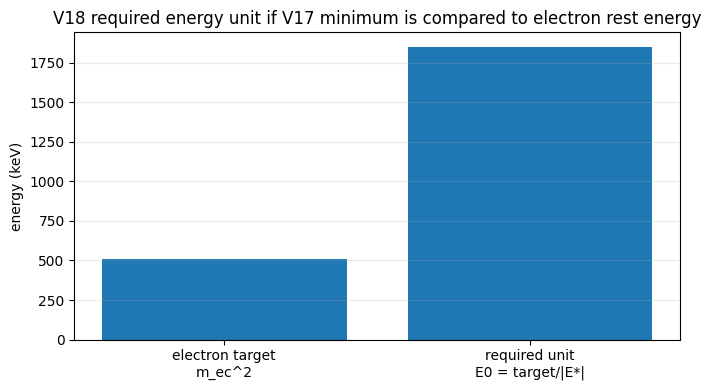

In [4]:
# ============================================================
# CELL 4 — required ECSM energy scale implied by V17 if compared to m_e c^2
# ============================================================

E_star_abs = abs(V17_MINIMUM["E_star_dimless"])
R_star = V17_MINIMUM["R_star_dimless"]

E0_required_J = E_electron_J / E_star_abs
E0_required_keV = E0_required_J / keV
E0_required_MeV = E0_required_J / MeV

xi_direct_required_m = hbar * c / E0_required_J
tau_direct_required_s = hbar / E0_required_J

xi_packet_required_m = hbar * c / (R_star * E0_required_J)
Rphys_packet_required_m = R_star * xi_packet_required_m

scale_target = {
    "E_star_abs_dimless": E_star_abs,
    "R_star_dimless": R_star,
    "electron_rest_energy_target_keV": E_electron_keV,
    "E0_required_keV_if_compared_to_electron": E0_required_keV,
    "E0_required_MeV_if_compared_to_electron": E0_required_MeV,
    "xi_direct_required_m": xi_direct_required_m,
    "xi_direct_required_fm": xi_direct_required_m / 1e-15,
    "tau_direct_required_s": tau_direct_required_s,
    "xi_direct_over_reduced_compton": xi_direct_required_m / lambda_C_reduced,
    "xi_packet_required_m": xi_packet_required_m,
    "xi_packet_required_fm": xi_packet_required_m / 1e-15,
    "Rphys_packet_required_m": Rphys_packet_required_m,
    "Rphys_packet_required_fm": Rphys_packet_required_m / 1e-15,
    "packet_radius_over_reduced_compton": Rphys_packet_required_m / lambda_C_reduced
}

print(json.dumps(scale_target, indent=2))
pd.DataFrame([scale_target]).to_csv(OUT_DIR / "required_scale_closure_target_v18.csv", index=False)

fig, ax = plt.subplots(figsize=(7,4))
labels = ["electron target\nm_ec^2", "required unit\nE0 = target/|E*|"]
vals = [E_electron_keV, E0_required_keV]
ax.bar(labels, vals)
ax.set_ylabel("energy (keV)")
ax.set_title("V18 required energy unit if V17 minimum is compared to electron rest energy")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v18_required_energy_unit.png", dpi=180)
plt.show()

,closure_convention,required_xi_m,required_xi_fm,required_tau_s,literal_packet_radius_fm
0,direct: E0 = hbar c / xi,1.067234e-13,106.723374,3.559909e-22,433.078465
1,packet-indexed: E0 = hbar c / (R* xi),2.629980e-14,26.299803,8.772670e-23,106.723374


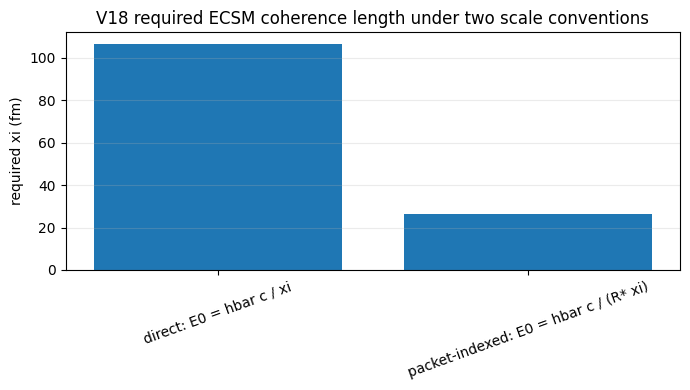

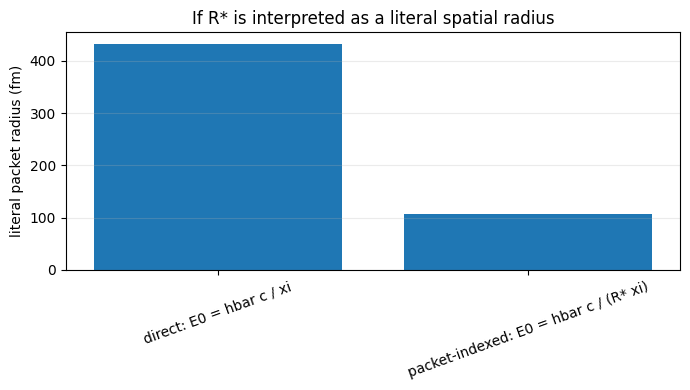

In [5]:
# ============================================================
# CELL 5 — required length/time scale diagnostics
# ============================================================

req_df = pd.DataFrame([
    {"closure_convention": "direct: E0 = hbar c / xi",
     "required_xi_m": xi_direct_required_m,
     "required_xi_fm": xi_direct_required_m/1e-15,
     "required_tau_s": tau_direct_required_s,
     "literal_packet_radius_fm": R_star * xi_direct_required_m / 1e-15},
    {"closure_convention": "packet-indexed: E0 = hbar c / (R* xi)",
     "required_xi_m": xi_packet_required_m,
     "required_xi_fm": xi_packet_required_m/1e-15,
     "required_tau_s": xi_packet_required_m / c,
     "literal_packet_radius_fm": Rphys_packet_required_m/1e-15},
])
req_df.to_csv(OUT_DIR / "required_length_time_scales_v18.csv", index=False)
display(req_df)

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(req_df["closure_convention"], req_df["required_xi_fm"])
ax.set_ylabel("required xi (fm)")
ax.set_title("V18 required ECSM coherence length under two scale conventions")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v18_required_xi_by_convention.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(req_df["closure_convention"], req_df["literal_packet_radius_fm"])
ax.set_ylabel("literal packet radius (fm)")
ax.set_title("If R* is interpreted as a literal spatial radius")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v18_literal_radius_warning.png", dpi=180)
plt.show()

In [6]:
# ============================================================
# CELL 6 — candidate dimensional closures without using m_e as fit
# ============================================================

p_grid = np.arange(-2, 9, 1)
xi_grid_m = np.logspace(-18, -9, 400)
rows = []

for p in p_grid:
    for xi in xi_grid_m:
        E0 = (alpha_em**p) * hbar*c / xi
        Ephys = E_star_abs * E0
        rows.append({
            "p_alpha": int(p),
            "xi_m": xi,
            "xi_fm": xi/1e-15,
            "E0_keV": E0/keV,
            "Ephys_keV_from_v17": Ephys/keV,
            "ratio_to_electron_target": Ephys/E_electron_J
        })

closure_scan = pd.DataFrame(rows)
closure_scan.to_csv(OUT_DIR / "alpha_power_length_closure_scan_v18.csv", index=False)

closest = []
for p, g in closure_scan.groupby("p_alpha"):
    idx = np.argmin(np.abs(np.log(g["ratio_to_electron_target"].values)))
    closest.append(g.iloc[idx].to_dict())
closest_df = pd.DataFrame(closest)
closest_df.to_csv(OUT_DIR / "nearest_alpha_power_closure_points_v18.csv", index=False)
closest_df

,p_alpha,xi_m,xi_fm,E0_keV,Ephys_keV_from_v17,ratio_to_electron_target
0,-2.0,1.000000e-09,1000000.000000,3.705577e+03,1.024115e+03,2.004144e+00
1,-1.0,1.489129e-11,14891.290324,1.815887e+03,5.018592e+02,9.821140e-01
2,0.0,1.071705e-13,107.170483,1.841244e+03,5.088671e+02,9.958281e-01
3,1.0,7.712906e-16,0.771291,1.866955e+03,5.159728e+02,1.009734e+00
4,2.0,5.550868e-18,0.005551,1.893024e+03,5.231778e+02,1.023833e+00
5,3.0,1.000000e-18,0.001000,7.668006e+01,2.119218e+01,4.147205e-02
6,4.0,1.000000e-18,0.001000,5.595615e-01,1.546468e-01,3.026362e-04
7,5.0,1.000000e-18,0.001000,4.083317e-03,1.128512e-03,2.208443e-06
8,6.0,1.000000e-18,0.001000,2.979741e-05,8.235150e-06,1.611579e-08
9,7.0,1.000000e-18,0.001000,2.174422e-07,6.009480e-08,1.176026e-10


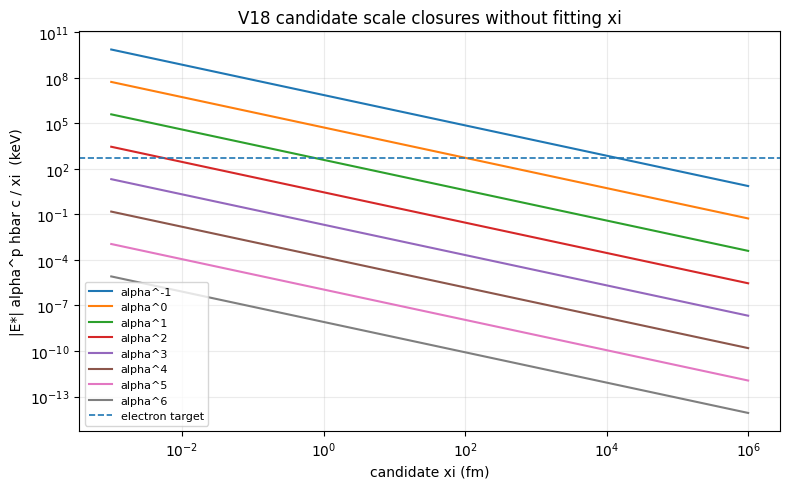

In [7]:
# ============================================================
# CELL 7 — plot closure scan: physical target is a diagnostic line
# ============================================================

fig, ax = plt.subplots(figsize=(8,5))
for p in [-1, 0, 1, 2, 3, 4, 5, 6]:
    g = closure_scan[closure_scan["p_alpha"] == p]
    ax.plot(g["xi_fm"], g["Ephys_keV_from_v17"], label=f"alpha^{p}")
ax.axhline(E_electron_keV, linestyle="--", linewidth=1.2, label="electron target")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("candidate xi (fm)")
ax.set_ylabel("|E*| alpha^p hbar c / xi  (keV)")
ax.set_title("V18 candidate scale closures without fitting xi")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v18_alpha_power_length_closure_scan.png", dpi=180)
plt.show()

Planck energy (GeV): 1.2208901282098643e+19
Required E0 / Planck E: 1.5144339679901927e-22
Nearest alpha^p point:
p_alpha                       1.000000e+01
alpha_power                   4.282065e-22
E0_from_planck_alpha_p_keV    5.227931e+03
ratio_to_required_E0          2.827502e+00
Name: 10, dtype: float64


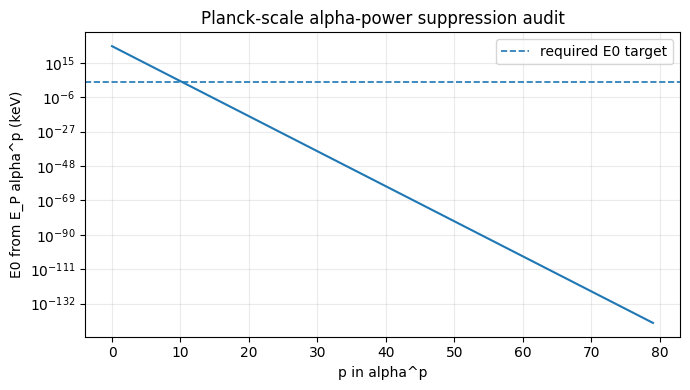

In [8]:
# ============================================================
# CELL 8 — Planck-scale suppression audit
# ============================================================

E_planck_J = math.sqrt(hbar * c**5 / G)
E_planck_GeV = E_planck_J / (1e9*eV)
required_suppression_from_planck = E0_required_J / E_planck_J

p_values = np.arange(0, 80)
supp = alpha_em ** p_values
planck_df = pd.DataFrame({
    "p_alpha": p_values,
    "alpha_power": supp,
    "E0_from_planck_alpha_p_keV": (E_planck_J * supp) / keV,
    "ratio_to_required_E0": (E_planck_J * supp) / E0_required_J
})
planck_df.to_csv(OUT_DIR / "planck_alpha_suppression_audit_v18.csv", index=False)

nearest_planck = planck_df.iloc[np.argmin(np.abs(np.log(planck_df["ratio_to_required_E0"])))]
print("Planck energy (GeV):", E_planck_GeV)
print("Required E0 / Planck E:", required_suppression_from_planck)
print("Nearest alpha^p point:")
print(nearest_planck)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(planck_df["p_alpha"], planck_df["E0_from_planck_alpha_p_keV"])
ax.axhline(E0_required_keV, linestyle="--", linewidth=1.2, label="required E0 target")
ax.set_yscale("log")
ax.set_xlabel("p in alpha^p")
ax.set_ylabel("E0 from E_P alpha^p (keV)")
ax.set_title("Planck-scale alpha-power suppression audit")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_v18_planck_alpha_suppression_audit.png", dpi=180)
plt.show()

In [9]:
# ============================================================
# CELL 9 — radius/literal-size consistency warning
# ============================================================

electron_radius_bound_m = 1e-19  # rough diagnostic bound scale, not used for fitting
radius_warning_df = pd.DataFrame([
    {
        "interpretation": "direct convention, literal R*xi",
        "literal_radius_m": R_star * xi_direct_required_m,
        "literal_radius_fm": R_star * xi_direct_required_m/1e-15,
        "ratio_to_1e_minus_19_m_bound": (R_star * xi_direct_required_m) / electron_radius_bound_m,
        "literal_radius_problem_if_taken_as_charge_radius": (R_star * xi_direct_required_m) > electron_radius_bound_m,
    },
    {
        "interpretation": "packet-indexed convention, literal R*xi",
        "literal_radius_m": Rphys_packet_required_m,
        "literal_radius_fm": Rphys_packet_required_m/1e-15,
        "ratio_to_1e_minus_19_m_bound": Rphys_packet_required_m / electron_radius_bound_m,
        "literal_radius_problem_if_taken_as_charge_radius": Rphys_packet_required_m > electron_radius_bound_m,
    },
])
radius_warning_df.to_csv(OUT_DIR / "literal_radius_consistency_warning_v18.csv", index=False)
radius_warning_df

,interpretation,literal_radius_m,literal_radius_fm,ratio_to_1e_minus_19_m_bound,literal_radius_problem_if_taken_as_charge_radius
0,"direct convention, literal R*xi",4.330785e-13,433.078465,4.330785e+06,True
1,"packet-indexed convention, literal R*xi",1.067234e-13,106.723374,1.067234e+06,True


In [10]:
# ============================================================
# CELL 10 — no-mass-insertion audit
# ============================================================

audit = {
    "v17_dimensionless_minimum_fixed_before_target_comparison": True,
    "electron_mass_used_as_target_only": True,
    "E0_set_equal_to_511keV": False,
    "E0_required_calculated_from_target_for_diagnostic": True,
    "scale_fit_performed_against_electron_mass": False,
    "physical_hbar_c_used_for_dimensional_mapping_only": True,
    "electron_mass_derivation_claimed": False,
    "literal_radius_warning_triggered": bool(radius_warning_df["literal_radius_problem_if_taken_as_charge_radius"].any()),
    "v19_required_for_non_arbitrary_medium_scale_generator": True
}

print(json.dumps(audit, indent=2))
with open(OUT_DIR / "no_mass_insertion_audit_v18.json", "w") as f:
    json.dump(audit, f, indent=2)

{
  "v17_dimensionless_minimum_fixed_before_target_comparison": true,
  "electron_mass_used_as_target_only": true,
  "E0_set_equal_to_511keV": false,
  "E0_required_calculated_from_target_for_diagnostic": true,
  "scale_fit_performed_against_electron_mass": false,
  "physical_hbar_c_used_for_dimensional_mapping_only": true,
  "electron_mass_derivation_claimed": false,
  "literal_radius_warning_triggered": true,
  "v19_required_for_non_arbitrary_medium_scale_generator": true
}


In [11]:
# ============================================================
# CELL 11 — final V18 verdict
# ============================================================

criteria = [
    ("inherits q=-1 packet scaffold", abs(V17_PACKET["q_eff"] + 1.0), abs(V17_PACKET["q_eff"] + 1.0) < 1e-2),
    ("inherits finite V17 rest-energy minimum", V17_MINIMUM["E_star_dimless"], np.isfinite(V17_MINIMUM["E_star_dimless"])),
    ("V17 minimum not boundary artefact", int(V17_MINIMUM["boundary_minimum"]), not V17_MINIMUM["boundary_minimum"]),
    ("required E0 target computed", E0_required_keV, E0_required_keV > 0),
    ("required xi direct finite", xi_direct_required_m, np.isfinite(xi_direct_required_m) and xi_direct_required_m > 0),
    ("required tau direct finite", tau_direct_required_s, np.isfinite(tau_direct_required_s) and tau_direct_required_s > 0),
    ("candidate alpha-power scan completed", len(closure_scan), len(closure_scan) > 0),
    ("Planck suppression audit completed", required_suppression_from_planck, required_suppression_from_planck > 0),
    ("no E0=511keV shortcut", int(audit["E0_set_equal_to_511keV"]), not audit["E0_set_equal_to_511keV"]),
    ("no electron-mass fit performed", int(audit["scale_fit_performed_against_electron_mass"]), not audit["scale_fit_performed_against_electron_mass"]),
    ("literal radius warning explicitly tracked", int(audit["literal_radius_warning_triggered"]), audit["literal_radius_warning_triggered"]),
    ("V19 handoff required", int(audit["v19_required_for_non_arbitrary_medium_scale_generator"]), audit["v19_required_for_non_arbitrary_medium_scale_generator"]),
]

verdict_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
verdict_df.to_csv(OUT_DIR / "final_scale_closure_v18_verdict.csv", index=False)
display(verdict_df)

n_pass = int(verdict_df["pass"].sum())
n_criteria = int(len(verdict_df))

if n_pass == n_criteria:
    final_label = (
        "PASS_NARROW: V18 converts the V17 dimensionless rest-energy minimum into a "
        "scale-closure target and rejects direct electron-mass insertion, but does not yet "
        "derive the physical electron mass."
    )
else:
    final_label = (
        "PARTIAL: V18 scale-closure audit incomplete; inspect failed criteria before promotion."
    )

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": V17_PACKET["q_eff"],
    "R_star_dimless": R_star,
    "E_star_dimless": V17_MINIMUM["E_star_dimless"],
    "E0_required_keV_if_compared_to_electron": E0_required_keV,
    "xi_direct_required_fm": xi_direct_required_m / 1e-15,
    "tau_direct_required_s": tau_direct_required_s,
    "xi_packet_required_fm": xi_packet_required_m / 1e-15,
    "literal_packet_radius_warning": bool(radius_warning_df["literal_radius_problem_if_taken_as_charge_radius"].any()),
    "electron_mass_derivation_claimed": False,
    "v19_required": True,
    "notes": (
        "V18 does not derive m_e. It shows what physical energy/length/time scale would be required "
        "to map the V17 finite dimensionless minimum toward m_e c^2, while auditing against the "
        "forbidden shortcut E0 = 511 keV. The next step is a non-arbitrary ECSM medium-scale generator."
    )
}

print("Final label:", final_label)
print(json.dumps(summary, indent=2))

with open(OUT_DIR / "run_summary_v18.json", "w") as f:
    json.dump(summary, f, indent=2)

,criterion,value,pass
0,inherits q=-1 packet scaffold,6.964280e-04,True
1,inherits finite V17 rest-energy minimum,-2.763714e-01,True
2,V17 minimum not boundary artefact,0.000000e+00,True
3,required E0 target computed,1.848957e+03,True
4,required xi direct finite,1.067234e-13,True
5,required tau direct finite,3.559909e-22,True
6,candidate alpha-power scan completed,4.400000e+03,True
7,Planck suppression audit completed,1.514434e-22,True
8,no E0=511keV shortcut,0.000000e+00,True
9,no electron-mass fit performed,0.000000e+00,True


Final label: PASS_NARROW: V18 converts the V17 dimensionless rest-energy minimum into a scale-closure target and rejects direct electron-mass insertion, but does not yet derive the physical electron mass.
{
  "final_label": "PASS_NARROW: V18 converts the V17 dimensionless rest-energy minimum into a scale-closure target and rejects direct electron-mass insertion, but does not yet derive the physical electron mass.",
  "n_pass": 12,
  "n_criteria": 12,
  "q_eff": -0.9993035720499918,
  "R_star_dimless": 4.057953281423804,
  "E_star_dimless": -0.27637139082292783,
  "E0_required_keV_if_compared_to_electron": 1848.9574813449199,
  "xi_direct_required_fm": 106.72337375484807,
  "tau_direct_required_s": 3.559908560303011e-22,
  "xi_packet_required_fm": 26.299803460872354,
  "literal_packet_radius_warning": true,
  "electron_mass_derivation_claimed": false,
  "v19_required": true,
  "notes": "V18 does not derive m_e. It shows what physical energy/length/time scale would be required to map the

In [12]:
# ============================================================
# CELL 12 — manifest and zip export
# ============================================================

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT_DIR.iterdir()])})
manifest.to_csv(OUT_DIR / "manifest_v18.csv", index=False)
display(manifest)

zip_path = Path(str(OUT_DIR) + ".zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT_DIR.iterdir():
        z.write(p, arcname=p.name)

print("Zipped output:", zip_path)

,file
0,alpha_power_length_closure_scan_v18.csv
1,fig_v18_alpha_power_length_closure_scan.png
2,fig_v18_literal_radius_warning.png
3,fig_v18_planck_alpha_suppression_audit.png
4,fig_v18_required_energy_unit.png
5,fig_v18_required_xi_by_convention.png
6,final_scale_closure_v18_verdict.csv
7,fixed_packet_summary_v18.csv
8,literal_radius_consistency_warning_v18.csv
9,nearest_alpha_power_closure_points_v18.csv


Zipped output: ecsm_electron_like_scale_closure_v18_out.zip
